In [1]:
import numpy as np
import math
from datetime import datetime
import os
import subprocess #install to run bash lines from python
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

import sys
%load_ext autoreload
%autoreload 1
%aimport get_manobs_soundings_pr_df


import microphy_p3_qv_sat
import kin1d_functions


# Import soundings

In [2]:
file_soundings = ['upperair.sounding.202203060620.UQAM-Sorel.txt',
                  'upperair.sounding.202203060800.UQAM-Sorel.txt',
                  'upperair.sounding.202203061000.UQAM-Sorel.txt',
                  'upperair.sounding.202203061200.UQAM-Sorel.txt',
                #   'upperair.sounding.202203061400.UQAM-Sorel.txt',
                #   'upperair.sounding.202203061415.UQAM-Sorel.txt',
                  'upperair.sounding.202203061440.UQAM-Sorel.txt',
                  'upperair.sounding.202203061600.UQAM-Sorel.txt']


path = '/home/rml000/sitestore8/UQAM/projet_margaux/Pour_Mathieu_fig4/soundings_wintremix/'
dfs_sounding = []
for file in file_soundings:
    print(file)
    dfs_sounding.append(get_manobs_soundings_pr_df.read_soundings_data(path + file)[:1000])


upperair.sounding.202203060620.UQAM-Sorel.txt
upperair.sounding.202203060800.UQAM-Sorel.txt
upperair.sounding.202203061000.UQAM-Sorel.txt
upperair.sounding.202203061200.UQAM-Sorel.txt
upperair.sounding.202203061440.UQAM-Sorel.txt
upperair.sounding.202203061600.UQAM-Sorel.txt


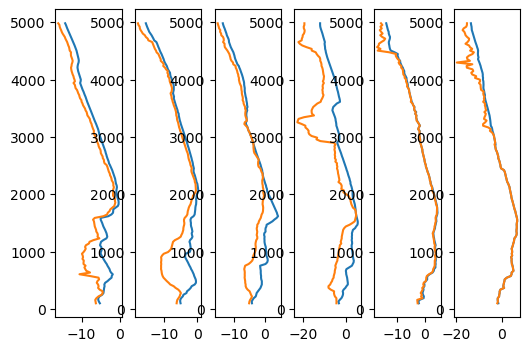

In [3]:
if 'df_sounding' not in globals():
    df_sounding = dfs_sounding[0].copy()

if 'z' not in globals():
    z = np.linspace(50., 5000., 496)

if 'height' in df_sounding.columns:
    df_sounding = df_sounding.sort_values('height').set_index('height')
else:
    df_sounding = df_sounding.sort_index()

df_sounding = df_sounding[~df_sounding.index.duplicated(keep='first')]

df_interp = (
    df_sounding[['Press', 'Temp', 'RelHum', 'Tw']]
    .reindex(df_sounding.index.union(z))
    .interpolate(method='index')
    .loc[z]
)


dfs_sounding_int = []
z = np.linspace(100.,5000.,495)

for i in range(len(dfs_sounding)):
    df_sounding = dfs_sounding[i]
    df_sounding = df_sounding.sort_values("height").set_index("height")
    df_sounding = df_sounding[~df_sounding.index.duplicated(keep='first')]
    df_sounding = df_sounding[['Press','Temp','RelHum','Tw']]
    df_interp    = (
      df_sounding.reindex(df_sounding.index.union(z))
      .interpolate(method="index")
      .loc[z]
      .reset_index())
    df_interp['height'] = z
    # df_interp['height'] = df_interp.index
    dfs_sounding_int.append(df_interp)
    
    if i==3:
        df_interp.loc[332:355, 'RelHum'] = np.nan
        df_interp.loc[:, 'RelHum'] = df_interp.loc[:, 'RelHum'].interpolate(method='linear')
    
fig,ax= plt.subplots(1,len(dfs_sounding),figsize=(6,4))
for i in range(len(dfs_sounding_int)):    
    df_interp = dfs_sounding_int[i]
    # if i==0:
    #     df_interp.loc[:,'QV'] = np.array([kin1d_functions.qv_from_rh(dfs_sounding_int[1].iloc[j].RelHum/100.,df_interp.iloc[j].Temp+273.15,dfs_sounding_int[0].iloc[j].Press*100.) for j in range(len(df_interp.Temp)) ])
    #     df_interp.loc[:,'TD'] = np.array([kin1d_functions.dewpoint_from_rh(df_interp.iloc[j].Temp+273.15,dfs_sounding_int[1].iloc[j].RelHum/100.,) for j in range(len(df_interp.Temp)) ]) - 273.15    
    # else:
    df_interp.loc[:,'QV'] = np.array([kin1d_functions.qv_from_rh(df_interp.iloc[j].RelHum/100.,df_interp.iloc[j].Temp+273.15,dfs_sounding_int[0].iloc[j].Press*100.) for j in range(len(df_interp.Temp)) ])
    df_interp.loc[:,'TD'] = np.array([kin1d_functions.dewpoint_from_rh(df_interp.iloc[j].Temp+273.15,df_interp.iloc[j].RelHum/100.,) for j in range(len(df_interp.Temp)) ]) - 273.15

    df_interp = df_interp.rename(columns={'Press':'PRES', 'height':'HGHT','Temp':'TEMP','TD':'DWPT','RelHum':'RELH'})
    df_interp = df_interp.iloc[::3]
    
    
    ax[i].plot(df_interp['TEMP'],df_interp['HGHT'])
    ax[i].plot(df_interp['DWPT'],df_interp['HGHT'])

    
    kin1d_functions.write_tprofile_file(df_interp, path='p31d_sip-ffd-mod-notempdep-evolving_T_PR_SOREL_IOP8/temp_to_use_' + str(i) + '.dat') 






# Simulation

In [4]:
def produce_sim_and_output(df_manobs_iop8_sorel_in,inputs_pr):
    
    
    df_manobs_iop8_sorel_copy = df_manobs_iop8_sorel_in.copy()
    
    df_manobs_iop8_sorel_in.loc[:,'pr'] = inputs_pr
    # Resample to 1-second frequency and interpolate pr
    df_manobs_iop8_sorel_1s = df_manobs_iop8_sorel_in[['pr']].resample('1s').interpolate(method='time')        
    df_manobs_iop8_sorel_1s_mod_pr = df_manobs_iop8_sorel_1s.copy()
    df_manobs_iop8_sorel_1s_mod_pr['pr']  = df_manobs_iop8_sorel_1s_mod_pr['pr']
    # df_manobs_iop8_sorel_1s_mod_pr['pr'] = df_manobs_iop8_sorel_1s_mod_pr['pr'].apply(pr_factor)

    shift_s = - 60*30 # Snow initialize at 4000 m, and falling at 1 m/s, so it takes 4000 s to reach the ground. So we shift the qitop/nitop by -4000 s

    n_pad = abs(int(shift_s))

    pad_index = pd.date_range(
        end=df_manobs_iop8_sorel_1s_mod_pr.index[0] - pd.Timedelta(seconds=1),
        periods=n_pad,
        freq='s',
    )

    pad_df = pd.DataFrame(0.0, index=pad_index, columns=df_manobs_iop8_sorel_1s_mod_pr.columns)

    df_manobs_iop8_sorel_1s_mod_pr = (
        pd.concat([pad_df, df_manobs_iop8_sorel_1s_mod_pr], axis=0)
        .sort_index()
    )

    df_manobs_iop8_sorel_1s_mod_pr = df_manobs_iop8_sorel_1s_mod_pr.shift(shift_s)#(periods=shift_s, freq='s')


    df_manobs_iop8_sorel_1s_mod_pr = (
        df_manobs_iop8_sorel_1s_mod_pr.fillna(0.0)
    )

    df_manobs_iop8_sorel_1s_mod_pr['qitop'] = df_manobs_iop8_sorel_1s_mod_pr['pr'].apply(lambda x: kin1d_functions.pr_to_N_Q_2(x,all_drop_same_size=False)[0])
    df_manobs_iop8_sorel_1s_mod_pr['nitop'] = df_manobs_iop8_sorel_1s_mod_pr['pr'].apply(lambda x: kin1d_functions.pr_to_N_Q_2(x,all_drop_same_size=False)[1])

    df_manobs_iop8_sorel_1s_to_write = df_manobs_iop8_sorel_1s_mod_pr[['qitop', 'nitop']]


    df_manobs_iop8_sorel_1s_to_write.to_csv('p31d_sip-ffd-mod-notempdep-evolving_T_PR_SOREL_IOP8/df_manobs_iop8_sorel_1s.csv',index=False)

    fig,ax=plt.subplots(1,figsize=(6,3))
    ax.plot(df_manobs_iop8_sorel_copy.index, df_manobs_iop8_sorel_copy.pr,color='C0', label='Observed PR')
    ax.plot(df_manobs_iop8_sorel_1s_mod_pr.index, df_manobs_iop8_sorel_1s_mod_pr.pr,color='C1', label='Modified PR')
    ax.legend()
    plt.show()



    path_model = 'p31d_sip-ffd-mod-notempdep-evolving_T_PR_SOREL_IOP8/'
    fort8000,fort9000, sfcprec, outQ, outN = kin1d_functions.model_run(\
        path_model, input_dict={'liqFrac':'.false.','n_iceCat':2,'dt_p3':1.,'ttotmin':len(df_manobs_iop8_sorel_1s_to_write)/60,'bimm':2,'outfreq':1.,'nk_input':102},
        compilation=True)
    ncQ = kin1d_functions.to_netcdf(outQ)     # Output containing mass mixing ratio of the different species, and atmosphere conditions profile
    ncN = kin1d_functions.to_netcdf(outN)     # Output containing number mixing ratio of the different species, as well as riming and ice density and ice size 
    nc8 = kin1d_functions.to_netcdf(fort8000) # Output containing mass rates of processes
    nc9 = kin1d_functions.to_netcdf(fort9000) # Output containing number rates of processes
    sfcprec.index.name = "time"
    ds_sfcprec = sfcprec.to_xarray()
    ds_all = xr.merge([ds_sfcprec, ncQ, ncN, nc8, nc9],compat='override')


    ds_all_copy = ds_all.copy()
    ds_all_copy = ds_all_copy.sel(time=slice(int(-shift_s),ds_all.time[-1]))

    pr_ts =( ds_all_copy.prt_sol + ds_all_copy.prt_liq)#.resample('1s').interpolate(method='time')
    df_pr_ts = pd.DataFrame({'pr':pr_ts.values},index= df_manobs_iop8_sorel_1s.index[::60])
    df_pr_ts = df_pr_ts.resample('10min').interpolate(method='time')


    plt.plot(df_manobs_iop8_sorel_copy.index, df_manobs_iop8_sorel_copy['pr'], color='C0', label='Target precip.')
    plt.plot(df_pr_ts.index, df_pr_ts['pr'], color='C1', label='Simulated  precip.')
    plt.legend()
    plt.show()
    
    output_pr = df_pr_ts['pr'].values
    return output_pr,ds_all


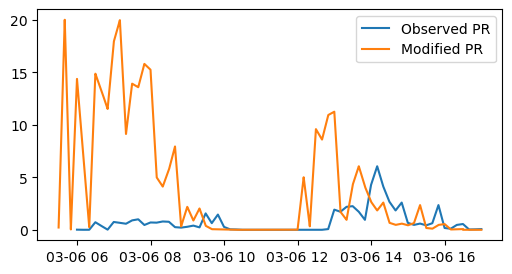

make: Entering directory '/fs/site8/eccc/crd/cccma/users/rml000/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/wintre-mix_fzra_and_pl/p31d_sip-ffd-mod-notempdep-evolving_T_PR_SOREL_IOP8'
rm -f *.o *.mod fort.* execld out_p3.dat out* sfcprec.dat
make: Leaving directory '/fs/site8/eccc/crd/cccma/users/rml000/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/wintre-mix_fzra_and_pl/p31d_sip-ffd-mod-notempdep-evolving_T_PR_SOREL_IOP8'
make: Entering directory '/fs/site8/eccc/crd/cccma/users/rml000/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/wintre-mix_fzra_and_pl/p31d_sip-ffd-mod-notempdep-evolving_T_PR_SOREL_IOP8'
rm -f input_kinematic_model.o
gfortran -I. -I. -fdefault-real-8 -fbounds-check -cpp -g -c -o input_kinematic_model.o input_kinematic_model.f90
rm -f microphy_p3.o
gfortran -I. -I. -fdefault-real-8 -fbounds-check -cpp -g -c -o microphy_p3.o microphy_p3.f90
rm -f routinesCld1d.o
gfortran -I. -I. -fdefault-real-8 -fbounds-check -cpp -g -c -o routi

cld1d.f90:739:16:

  739 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8
      |                1
cld1d.f90:739:33:

  739 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8
      |                                 1
cld1d.f90:739:50:

  739 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8
      |                                                  1
cld1d.f90:745:16:

  745 |         Ni1(1,k,3),Bg1(1,k,3)*10**8
      |                1
cld1d.f90:745:27:

  745 |         Ni1(1,k,3),Bg1(1,k,3)*10**8
      |                           1
cld1d.f90:754:16:

  754 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8,&
      |                1
cld1d.f90:754:33:

  754 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8,&
      |                                 1
cld1d.f90:754:50:

  754 |         Qg1(1,k,3)*10**8,Qi1(1,k,3)*10**8,Ql1(1,k,3)*10**8,&
      |                                                  1
cld1d.f90:755:16:

  755 |         Qg1(

rm -f execld.o
gfortran -I. -I. -fdefault-real-8 -fbounds-check -cpp -g -c -o execld.o execld.f90
rm -f execld
gfortran -I. -I. -fdefault-real-8 -fbounds-check -cpp -g   -o execld execld.o input_kinematic_model.o microphy_p3.o routinesCld1d.o   cld1d.o 
rm execld.o
make: Leaving directory '/fs/site8/eccc/crd/cccma/users/rml000/UQAM/projet_margaux/Pour_Mathieu_fig4/create_figure_papier/wintre-mix_fzra_and_pl/p31d_sip-ffd-mod-notempdep-evolving_T_PR_SOREL_IOP8'
Compiling..p31d_sip-ffd-mod-notempdep-evolving_T_PR_SOREL_IOP8/
Running..p31d_sip-ffd-mod-notempdep-evolving_T_PR_SOREL_IOP8/

 ** Remember to use compiler debug options for testing new code (modfify Makefile appropriately) **


  P3 microphysics: v5.5.1
    P3_INIT (reading/creating lookup tables)
      Reading table 1 [6.9-2momI] ...
      Reading table 2 [v6.2] ...
      Generating table for rain parameters ...
    P3_INIT DONE.

 Starting main loop... for        41400 timesteps

 DONE

Run completed
reading1
reading2
OKOKOK
qr

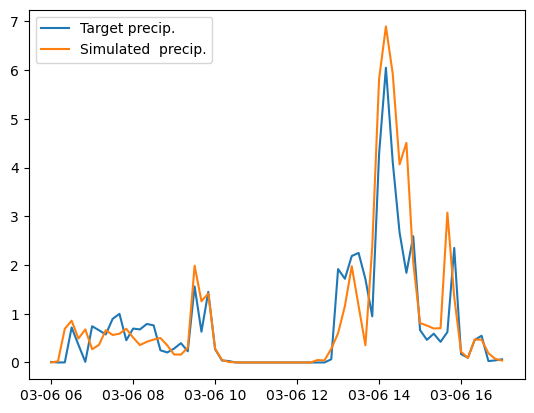

In [6]:
df_manobs = pd.read_csv('df_all_events_tw_29juillet2026.csv')

df_manobs_iop8_sorel = df_manobs.loc[((df_manobs.IOP=='IOP8') & (df_manobs.site=='Sorel'))]

df_manobs_iop8_sorel['rounded_time'] = pd.to_datetime(df_manobs_iop8_sorel['rounded_time'])
df_manobs_iop8_sorel = df_manobs_iop8_sorel.set_index('rounded_time')

# Resample to 1-second frequency and interpolate pr
# df_manobs_iop8_sorel_1s = df_manobs_iop8_sorel[['pr']].resample('1s').interpolate(method='time')
input_pr = df_manobs_iop8_sorel.loc[:,'pr'].copy()


# Manually tune precipitation rate
input_pr_mod = input_pr.copy()
input_pr_mod.loc['2022-03-06 06:10'] = input_pr_mod.loc['2022-03-06 06:10']+1
input_pr_mod.loc['2022-03-06 06:00':'2022-03-06 09:10'] = input_pr_mod.loc['2022-03-06 06:00':'2022-03-06 09:20'] * 20
input_pr_mod.loc['2022-03-06 09:20':'2022-03-06 10:30'] = input_pr_mod.loc['2022-03-06 09:20':'2022-03-06 10:20'] *1.4

input_pr_mod.loc['2022-03-06 12:40:00'] =  input_pr_mod.loc['2022-03-06 12:40:00'] + 1
input_pr_mod.loc['2022-03-06 12:20':'2022-03-06 13:30'] = input_pr_mod.loc['2022-03-06 12:20':'2022-03-06 13:30']  * 5


# Run simulation
output_pr,ds_all = produce_sim_and_output(df_manobs_iop8_sorel, input_pr_mod)
ds_all = ds_all.sel(time=slice(60*31,ds_all.time[-1]))



In [16]:
ds_all.to_netcdf(f"outputs_evolving_sim/ds_iop8_sorel.nc")

# Read output and plot

In [8]:
df_manobs = pd.read_csv('df_all_events_tw_29juillet2026.csv')
df_manobs_iop8_sorel = df_manobs.loc[((df_manobs.IOP=='IOP8') & (df_manobs.site=='Sorel'))]
df_manobs_iop8_sorel['rounded_time'] = pd.to_datetime(df_manobs_iop8_sorel['rounded_time'])
df_manobs_iop8_sorel = df_manobs_iop8_sorel.set_index('rounded_time')

df_manobs_iop8_sorel_1s = df_manobs_iop8_sorel[['pr']].resample('1s').interpolate(method='time')        
time_1min = df_manobs_iop8_sorel_1s.index[60::60]

ds_all = xr.open_dataset(f"outputs_evolving_sim/ds_iop8_sorel.nc")

# Compute RH, RHI
ds_all["esw"] = xr.apply_ufunc(lambda T:  microphy_p3_qv_sat.microphy_qv_sat.polysvp1(T,  0), ds_all["T"]+273.15 , vectorize=True)
ds_all["esi"] = xr.apply_ufunc(lambda T:  microphy_p3_qv_sat.microphy_qv_sat.polysvp1(T,  1), ds_all["T"]+273.15 , vectorize=True)
ds_all["e_w"] = xr.apply_ufunc(lambda Td: microphy_p3_qv_sat.microphy_qv_sat.polysvp1(Td, 0), ds_all["Td"]+273.15, vectorize=True)

ds_all["rh"]  = ds_all["e_w"]/ds_all["esw"]
ds_all["rhi"] = ds_all["e_w"]/ds_all["esi"]

In [9]:
def plot_iop5_troi_obs_pr(df_manobs_iop5_troi,ax):
    # color_list = {'SN and FZRA':'blue','SN and RA':'darkblue','None':'grey','No precip.':'grey','PL':'#1f77b4','FZRA':"#ff0e0e",'FZRA and PL':'#2ca02c','RA':'k','SN and PL':'cyan','SN':'cyan','RA and PL':'darkgreen'}

    # marker_list = {'SN and RA':'s','None':'_','No precip.':'_',    'PL':'s'  ,'FZRA':'s','FZRA and PL':'s','SN and FZRA':'s','RA and PL':'s','RA':'s','SN and PL':'s','SN':'s','RA and PL':'s'}




    color_list = {'SN and FZRA':'blue','SN and RA':'darkblue','None':'grey','No precip.':'grey','PL':'#1f77b4','FZRA':"#ff0e0e",'FZRA and PL':'#2ca02c','RA':'k','SN and PL':'cyan','SN':'cyan','RA and PL':'darkgreen'}
    marker_list = {'SN and FZRA':'s','SN and RA':'s','None':'_','No precip.':'_',    'PL':'o'  ,'FZRA':'^','FZRA and PL':'s','SN and FZRA':'s','RA and PL':'s','RA':'^','SN and PL':'o','SN':'o','RA and PL':'s'}
    marker_list = {'SN and RA':'s','None':'_','No precip.':'_',    'PL':'o'  ,'FZRA':'^','FZRA and PL':'s','SN and FZRA':'s','RA and PL':'s','RA':'s','SN and PL':'s','SN':'s','RA and PL':'s'}

    for v in ['PL','FZRA','FZRA and PL','RA','SN and PL','SN']:#df_manobs.manobs_with_mix.unique()[1:]:
        mask = df_manobs_iop5_troi.manobs_with_mix.values == v
        if (v=='FZRA and PL'):
            markerfacecolor    = 'none'# '#2ca02c'
            markerfacecoloralt = 'none'#'#2ca02c'
            markeredgecolor    = '#2ca02c'    
            ax.plot(df_manobs_iop5_troi[mask].index, df_manobs_iop5_troi[mask].pr, markerfacecolor=markerfacecolor,marker=marker_list[v],linestyle='None',markeredgecolor=markeredgecolor,label=v+' obs.')            
        elif ('and' in v):
            markerfacecolor    = color_list[v.split(' ')[0]]
            markerfacecoloralt = color_list[v.split(' ')[-1]]
            markeredgecolor = 'none'
            ax.plot(df_manobs_iop5_troi[mask].index, df_manobs_iop5_troi[mask].pr, markerfacecolor=markerfacecolor,markerfacecoloralt=markerfacecoloralt,marker=marker_list[v],fillstyle='left',linestyle='None',markeredgecolor=markeredgecolor,label=v+' obs.')            
        else:
            markerfacecolor    = 'none'# color_list[v]
            markerfacecoloralt = 'none'#color_list[v]
            markeredgecolor    = color_list[v]

            ax.plot(df_manobs_iop5_troi[mask].index, df_manobs_iop5_troi[mask].pr, markerfacecolor=markerfacecolor,marker=marker_list[v],linestyle='None',markeredgecolor=markeredgecolor,label=v+' obs.')
        


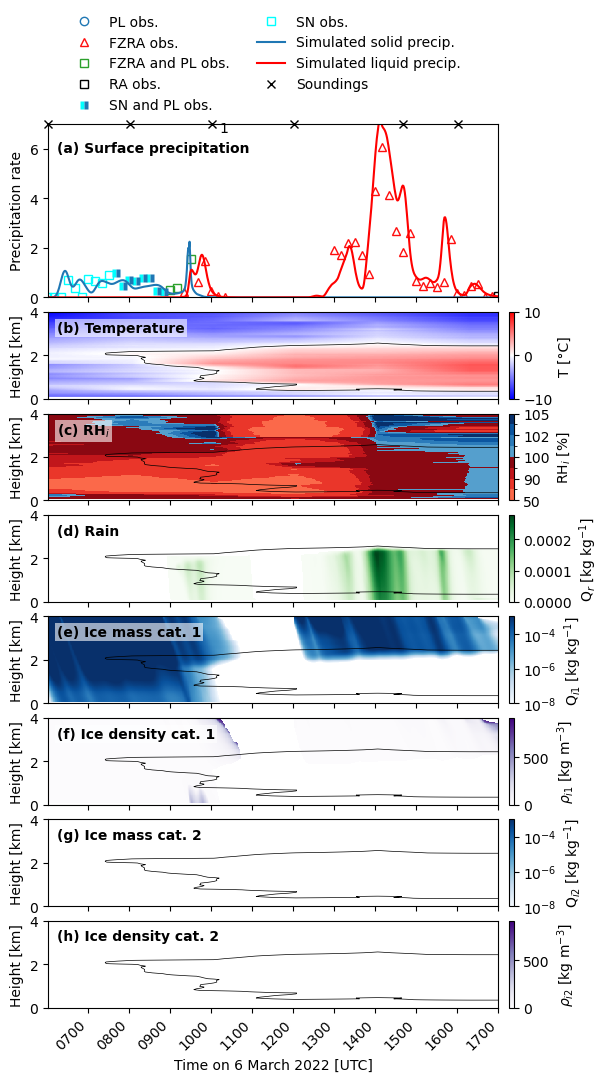

In [10]:
bounds =[50,70,90,95,100,101,102,103,105]

norm_rhi = mcolors.FuncNorm(
    (
        lambda x: np.interp(
            x,
            bounds,
            np.linspace(0,1,len(bounds)),#[0, 0.2, 0.45, 0.65, 0.85, 0.9, 0.94, 0.97, 1]
        ),
        lambda y: np.interp(
            y,
            np.linspace(0,1,len(bounds)),#[0, 0.2, 0.45, 0.65, 0.85, 0.9, 0.94, 0.97, 1],
            bounds
    )
)
)

cmap1 = plt.cm.Reds(np.linspace(0.5, 1, 200))   # 50-100
cmap2 = plt.cm.Blues(np.linspace(0.5, 1, 200))        # >100

# Combine them
colors = np.vstack((cmap1, cmap2))

cmap_rhi = mcolors.LinearSegmentedColormap.from_list(
    "combined_cmap",
    colors
)

z_km = ds_all.z[0, :] / 1000.


# Combined figure: precip panel + 7 vertical-structure panels
vmin = 1e-8
vmax = 1e-3
norm = matplotlib.colors.LogNorm(vmin=vmin, vmax=vmax)

fig, ax = plt.subplots(
    8, 1, figsize=(7, 13), sharex=True,
    gridspec_kw={"height_ratios": [2, 1, 1, 1, 1, 1, 1, 1]}
)

# --- Panel 1: surface precipitation ---
plot_iop5_troi_obs_pr(df_manobs_iop8_sorel, ax[0])
ax[0].plot(time_1min, ds_all.prt_sol, color='C0', label='Simulated solid precip.')
ax[0].plot(time_1min, ds_all.prt_liq, color='red', label='Simulated liquid precip.')
ax[0].set_ylim(0, 7)
ax[0].set_ylabel('Precipitation rate')
# Soundings 
times_soundings = [time_1min[0],time_1min[60*2],time_1min[60*4],time_1min[60*6],time_1min[60*8+40],time_1min[60*10]]
ax[0].plot(times_soundings, [7]*len(times_soundings), marker='x', color='k', linestyle='None',clip_on=False,label='Soundings')
ax[0].legend(ncol=2, bbox_to_anchor=(0.02, 1.7), loc='upper left', frameon=False)

ax[0].annotate('1', (times_soundings[2],7), textcoords="offset points", xytext=(5,-6), ha='left', fontsize=10)


# --- Panel 2: Temperature ---
norm_bwr = mcolors.TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
pc_T = ax[1].pcolormesh(time_1min, z_km, ds_all['T'].T,cmap='bwr',  norm=norm_bwr)
ax[1].contour(time_1min, z_km, ds_all['T'].T, colors='black', levels=[0], linewidths=0.5)

# --- Panel 3: RHi ---
bounds =[50,70,90,95,100,101,102,103,105]
norm_rhi = mcolors.BoundaryNorm(bounds,ncolors=256)
pc_rhi = ax[2].pcolormesh(time_1min, z_km, ds_all['rhi'].T*100., cmap=cmap_rhi, norm=norm_rhi)#,vmin=50, vmax=110)
ax[2].contour(time_1min, z_km, ds_all['T'].T, colors='black', levels=[0], linewidths=0.5)

# --- Panels 4..8: profiles ---
pcs = []
pcs.append(ax[3].pcolormesh(time_1min, z_km, ds_all.Qr.where(ds_all.Qr > 0).T, cmap='Greens'))
pcs.append(ax[4].pcolormesh(time_1min, z_km, ds_all.Qi.where(ds_all.Qi > vmin).T, cmap='Blues', norm=norm))
pcs.append(ax[5].pcolormesh(time_1min, z_km, (ds_all.diag_rhoi).where(ds_all.Qi > vmin).T, cmap='Purples', vmin=0, vmax=915))
pcs.append(ax[6].pcolormesh(time_1min, z_km, ds_all.Qi2.where(ds_all.Qi2 > vmin).T, cmap='Blues', norm=norm))
pcs.append(ax[7].pcolormesh(time_1min, z_km, (ds_all.diag_rhoi2).where(ds_all.Qi2 > vmin).T, cmap='Purples', vmin=0, vmax=915))

for i in range(3, 8):
    ax[i].contour(time_1min, z_km, ds_all['T'].T, colors='black', levels=[0], linewidths=0.5)

for i in range(1, 8):
    ax[i].set_ylim(0, 4)
    ax[i].set_ylabel('Height [km]')

ax[0].set_xlim(datetime(2022, 2, 22, 20, 0), datetime(2022, 2, 23, 6, 20))
for a in ax[:-1]:
    a.tick_params(labelbottom=False)

ax[-1].set_xlabel('Time on 6 March 2022 [UTC]')
ax[-1].xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%H%M'))
fig.autofmt_xdate(rotation=45)

panel_names = [
    '(a) Surface precipitation',
    '(b) Temperature',
    '(c) RH$_i$',
    '(d) Rain',
    '(e) Ice mass cat. 1',
    '(f) Ice density cat. 1',
    '(g) Ice mass cat. 2',
    '(h) Ice density cat. 2'
]
for i, name in enumerate(panel_names):
    ax[i].text(
        0.02, 0.9, name, transform=ax[i].transAxes,
        ha='left', va='top', fontsize=10, fontweight='bold',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.6, pad=1.5)
    )
    ax[i].set_xlim(time_1min[0], time_1min[-1])


fig.colorbar(pc_T,   ax=ax[1], pad=0.02).set_label('T [°C]')
fig.colorbar(pc_rhi, ax=ax[2], pad=0.02, ticks=bounds[::2]).set_label('RH$_i$ [%]')

labels = [
    r'Q$_r$ [kg kg$^{-1}$]',
    r'Q$_{i1}$ [kg kg$^{-1}$]',
    r'$\rho_{i1}$ [kg m$^{-3}$]',
    r'Q$_{i2}$ [kg kg$^{-1}$]',
    r'$\rho_{i2}$ [kg m$^{-3}$]'
]


for i, (pc, lab) in enumerate(zip(pcs, labels), start=3):
    fig.colorbar(pc, ax=ax[i], pad=0.02).set_label(lab)


cbar  = fig.colorbar(pc, ax=ax[0], pad=0.02).set_label(lab)
fig.delaxes(fig.axes[-1])


plt.subplots_adjust(hspace=0.15)
plt.savefig('../figures/sim_iop8_sorel.png', bbox_inches='tight',dpi=300)
plt.show()
